Accuracy : 0.8333

Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.70      0.78      0.74         9
   virginica       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30



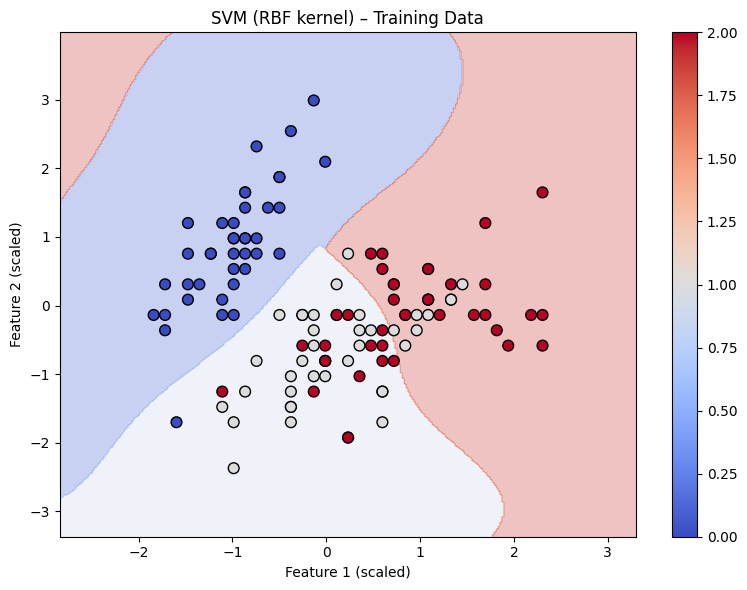

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── 1. Load Data ──────────────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data[:, :2], iris.target   # use first 2 features for visualization

# ── 2. Preprocess ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── 3. Train SVM ──────────────────────────────────────────────────────────────
model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
model.fit(X_train, y_train)

# ── 4. Evaluate ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,
      target_names=iris.target_names))

# ── 5. Plot Decision Boundary ─────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, title="SVM Decision Boundary"):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y,
                          cmap=plt.cm.coolwarm, edgecolors="k", s=60)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model, X_train, y_train,
                       title="SVM (RBF kernel) – Training Data")